# Домашнее задание "Продвинутая оптимизация".

### Задание

При фиксированном `seed=42` поэкспериментируйте с параметрами алгоритма [differential_evolution](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.differential_evolution.html): strategy, popsize, mutation.

Постройте графики количества итераций (`nit`) оптимизации [функции ackley](https://en.wikipedia.org/wiki/Ackley_function) от значения параметра. 

Подробнее о результате выдачи [тут](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.OptimizeResult.html).

In [1]:
import numpy as np
from scipy.optimize import differential_evolution
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
def ackley(x):
    arg1 = -0.2 * np.sqrt(0.5 * (x[0] ** 2 + x[1] ** 2))
    arg2 = 0.5 * (np.cos(2. * np.pi * x[0]) + np.cos(2. * np.pi * x[1]))
    return -20. * np.exp(arg1) - np.exp(arg2) + 20. + np.e

bounds = [(-10, 10), (-10, 10)]

result = differential_evolution(ackley, bounds, seed=42)
result

             message: Optimization terminated successfully.
             success: True
                 fun: 4.440892098500626e-16
                   x: [ 0.000e+00  0.000e+00]
                 nit: 92
                nfev: 2853
          population: [[ 0.000e+00  0.000e+00]
                       [ 0.000e+00  0.000e+00]
                       ...
                       [ 0.000e+00  0.000e+00]
                       [ 0.000e+00  0.000e+00]]
 population_energies: [ 4.441e-16  4.441e-16 ...  4.441e-16  4.441e-16]

,parameter,value,nit,nfev,fun,success
0,strategy,best1bin,92,2790,4.440892e-16,True
1,strategy,rand1bin,165,4980,4.440892e-16,True
2,strategy,best2bin,166,5010,4.440892e-16,True
3,strategy,randtobest1bin,103,3120,4.440892e-16,True
4,popsize,5,90,910,4.440892e-16,True
5,popsize,10,105,2120,4.440892e-16,True
6,popsize,15,92,2790,4.440892e-16,True
7,popsize,25,95,4800,4.440892e-16,True
8,popsize,40,102,8240,4.440892e-16,True
9,mutation,0.3,36,1110,4.440892e-16,True


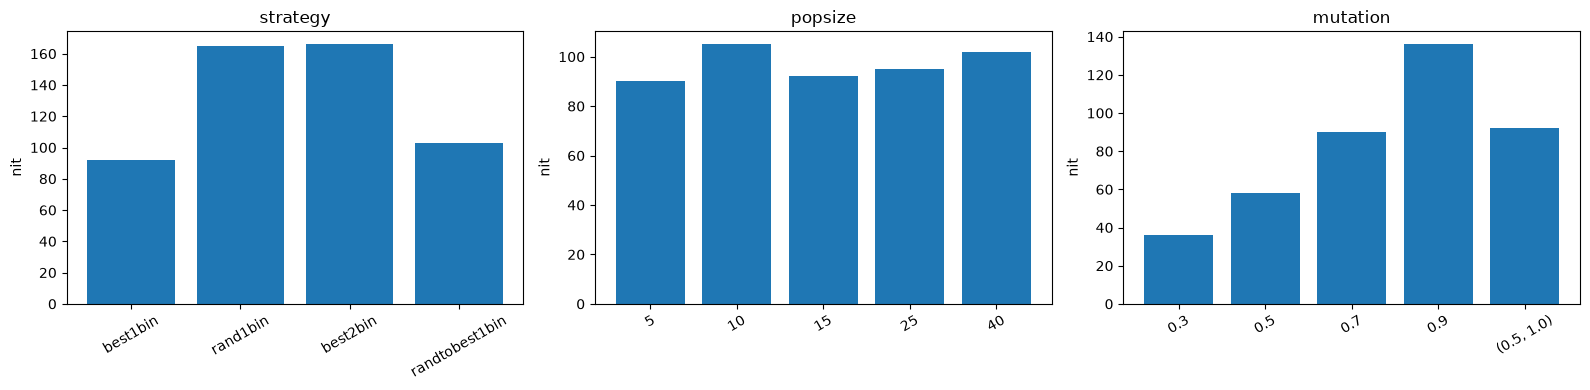

In [3]:
import pandas as pd
rows = []
experiments = {
    'strategy':['best1bin','rand1bin','best2bin','randtobest1bin'],
    'popsize':[5,10,15,25,40],
    'mutation':[0.3,0.5,0.7,0.9,(0.5,1.0)]
}
for parameter, values in experiments.items():
    for value in values:
        kwargs = dict(strategy='best1bin',popsize=15,mutation=(0.5,1.0))
        kwargs[parameter] = value
        r = differential_evolution(ackley,bounds,seed=42,polish=False,maxiter=1000,**kwargs)
        rows.append(dict(parameter=parameter,value=str(value),nit=r.nit,nfev=r.nfev,fun=r.fun,success=r.success))
table = pd.DataFrame(rows)
display(table)
fig, axes = plt.subplots(1,3,figsize=(16,4))
for ax, parameter in zip(axes,experiments):
    subset = table[table.parameter==parameter]
    ax.bar(subset.value,subset.nit); ax.set(title=parameter,ylabel='nit'); ax.tick_params(axis='x',rotation=30)
plt.tight_layout(); plt.show()
assert (table.fun < 1e-6).any()

### Дополнительное задание


Поэкспериментируйте с параметрами и оптимизацией через [minimize](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html):

In [4]:
from scipy.optimize import minimize

x0 = [0,0]

result_m = minimize(ackley, x0,  method='Nelder-Mead')
result_m

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 4.440892098500626e-16
             x: [ 0.000e+00  0.000e+00]
           nit: 8
          nfev: 17
 final_simplex: (array([[ 0.000e+00,  0.000e+00],
                       [-1.607e-05, -8.453e-06],
                       [-1.404e-06, -3.113e-05]]), array([ 4.441e-16,  5.136e-05,  8.816e-05]))

In [5]:
local_rows = []
for method in ['Nelder-Mead','Powell','BFGS']:
    for start in [[0,0],[1,1],[4,4]]:
        r = minimize(ackley,start,method=method,options={'maxiter':2000})
        local_rows.append(dict(method=method,start=str(start),fun=r.fun,nit=r.nit,success=r.success))
display(pd.DataFrame(local_rows))

,method,start,fun,nit,success
0,Nelder-Mead,"[0, 0]",4.440892e-16,8,True
1,Nelder-Mead,"[1, 1]",3.574452e+00,24,True
2,Nelder-Mead,"[4, 4]",1.099826e+01,30,True
3,Powell,"[0, 0]",4.440892e-16,1,True
4,Powell,"[1, 1]",3.574452e+00,2,True
5,Powell,"[4, 4]",1.099826e+01,2,True
6,BFGS,"[0, 0]",4.440892e-16,0,False
7,BFGS,"[1, 1]",2.228803e-08,1,False
8,BFGS,"[4, 4]",1.099826e+01,3,True


Вы также можете поэкспериментировать с [другими методами оптимизации](https://habr.com/ru/company/prequel/blog/568496/), но это не обязательно для зачета.


## Решение и проверка

Решение подготовлено AI по запросу владельца репозитория. Выполнение подтверждает работоспособность кода; самостоятельное владение материалом не оценивалось.

Один параметр меняется при остальных фиксированных. Seed=42 делает прогоны воспроизводимыми в выбранной версии SciPy. nit сравнивается вместе с nfev и качеством результата; один seed не доказывает общий рейтинг методов. Старт (0,0) уже находится в глобальном минимуме Ackley.